In [2]:
import matplotlib.pyplot as plt
import pandas as pd
import os
import seaborn as sns
import sys

In [3]:
base_path = r"C:\Users\M Hasan Rosyid\Desktop\Dataset_Project\LHS\LHS"
print(os.listdir(base_path))



['.ipynb_checkpoints', 'dynasim39lhs21.py', 'dynasim39lhs21in1.py', 'dynasim39lhs21in2.py', 'in1', 'in2', 'in3', 'lhs_points.csv', 'lhs_points.ipynb', 'preprocessing_pipeline_lhs.ipynb', 'results_lhs.ipynb', 'results_summary_lhs.csv', 'setcond39lhs1in1.py', 'setcond39lhs21.py', 'setcond39lhs21in2.py', '__pycache__']


In [4]:
path = os.path.join(base_path, "results_summary_lhs.csv")
summary = pd.read_csv(path)

print("Steady-state operating conditions:", summary.columns.tolist()) 
summary = summary.dropna(subset = ["Simulation no#"]).reset_index(drop=True)

Steady-state operating conditions: ['Simulation no#', 'Line ', 'Load', 'Wind1', 'Wind2', 'Wind3', 'flag', 'Sequence']


In [5]:
print("Total number of simulations:", len(summary))
summary.head(10)


Total number of simulations: 49980


,Simulation no#,Line,Load,Wind1,Wind2,Wind3,flag,Sequence
0,0.0,Line 04 - 05,0.9784,0.365,0.8582,0.3085,1.0,"[('Line 04 - 05DR1', '1.04'), ('Line 04 - 05DR..."
1,0.0,Line 06 - 07,0.9784,0.365,0.8582,0.3085,1.0,"[('Line 06 - 07DR1', '1.04'), ('Line 06 - 07DR..."
2,0.0,Line 06 - 11,0.9784,0.365,0.8582,0.3085,1.0,"[('Line 06 - 11DR1', '1.04'), ('Line 06 - 11DR..."
3,0.0,Line 10 - 11,0.9784,0.365,0.8582,0.3085,1.0,"[('Line 10 - 11DR2', '1.04'), ('Line 10 - 11DR..."
4,0.0,Line 10 - 13,0.9784,0.365,0.8582,0.3085,0.0,"[('Line 10 - 13DR2', '1.04'), ('Line 10 - 13DR..."
5,0.0,Line 13 - 14,0.9784,0.365,0.8582,0.3085,0.0,"[('Line 13 - 14DR2', '1.04'), ('Line 13 - 14DR..."
6,0.0,Line 16 - 19,0.9784,0.365,0.8582,0.3085,1.0,"[('Line 16 - 19DR1', '1.04'), ('Line 16 - 19DR..."
7,0.0,Line 16 - 21,0.9784,0.365,0.8582,0.3085,1.0,"[('Line 16 - 21DR1', '1.04'), ('Line 16 - 21DR..."
8,0.0,Line 16 - 24,0.9784,0.365,0.8582,0.3085,1.0,"[('Line 16 - 24DR1', '1.04'), ('Line 16 - 24DR..."
9,0.0,Line 26 - 28,0.9784,0.365,0.8582,0.3085,1.0,"[('Line 26 - 28DR1', '1.04'), ('Line 26 - 28DR..."


In [6]:
for i in [0., 1., 2., 3.]:
    f = int(i)
    print(f"Number of flag {f} simulations: {len(summary[summary['flag']==i])}")

Number of flag 0 simulations: 29802
Number of flag 1 simulations: 19650
Number of flag 2 simulations: 306
Number of flag 3 simulations: 222


In [7]:
flag0_no = summary['flag'] == 0.0
flag1_no = summary['flag'] == 1.0
print(f"Number of non-cascading events: {flag0_no.sum()}")
print(f"Number of cascading events: {flag1_no.sum()}")
print(f"Number of useful simulations is the sum of flag 0 and flag 1 simulations.\nUseful simulations: {flag0_no.sum() + flag1_no.sum()}")

Number of non-cascading events: 29802
Number of cascading events: 19650
Number of useful simulations is the sum of flag 0 and flag 1 simulations.
Useful simulations: 49452


In [11]:
summary["flag"].value_counts()
summary[summary["flag"] == 2].head()


,Simulation no#,Line,Load,Wind1,Wind2,Wind3,flag,Sequence
4182,123.0,Line 04 - 05,0.9664,0.0017,0.0466,0.1187,2.0,OPF cannot converge
4183,123.0,Line 06 - 07,0.9664,0.0017,0.0466,0.1187,2.0,OPF cannot converge
4184,123.0,Line 06 - 11,0.9664,0.0017,0.0466,0.1187,2.0,OPF cannot converge
4185,123.0,Line 10 - 11,0.9664,0.0017,0.0466,0.1187,2.0,OPF cannot converge
4186,123.0,Line 10 - 13,0.9664,0.0017,0.0466,0.1187,2.0,OPF cannot converge


Text(0.5, 1.0, 'Correlation matrix between the steady-state operating conditions of cascading events')

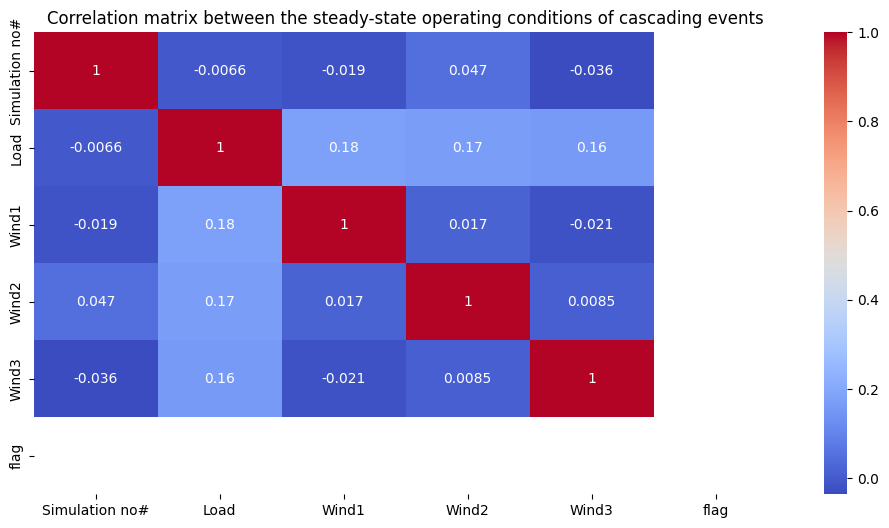

In [59]:
plt.figure(figsize=(12,6))
sns.heatmap(summary[summary['flag']==1.0].select_dtypes(include=['number']).corr(), annot=True, cmap='coolwarm')
plt.title("Correlation matrix between the steady-state operating conditions of cascading events")

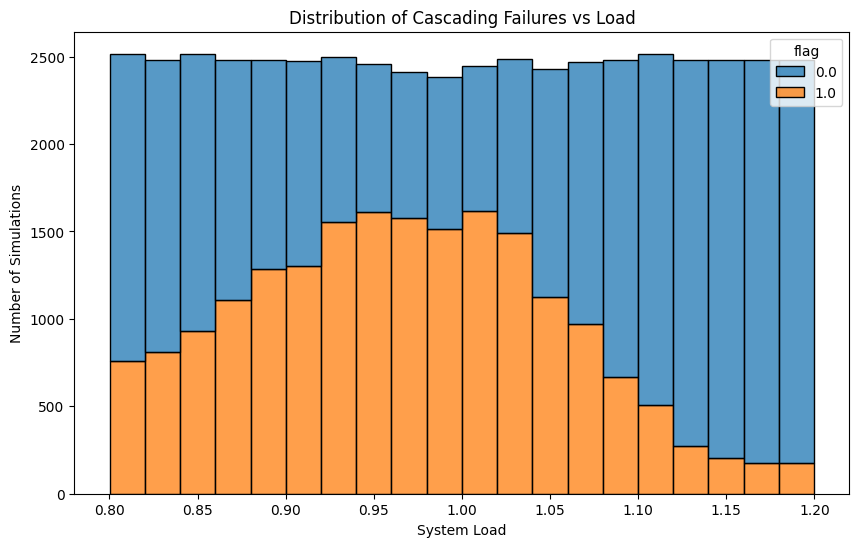

In [62]:
filtered = summary[summary['flag'].isin([0.0, 1.0])]
plt.figure(figsize=(10,6))
sns.histplot(data=filtered, x='Load', hue='flag', multiple='stack', bins=20)
plt.title("Distribution of Cascading Failures vs Load")
plt.xlabel("System Load")
plt.ylabel("Number of Simulations")
plt.show()

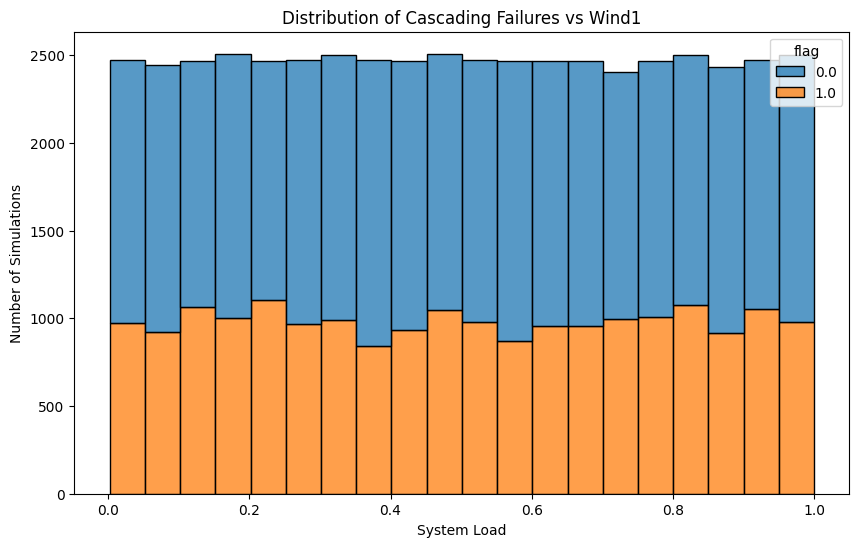

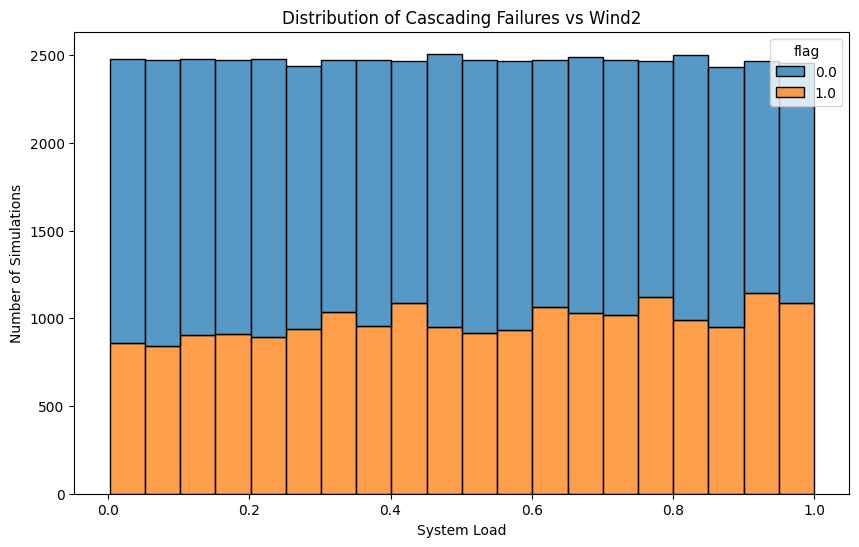

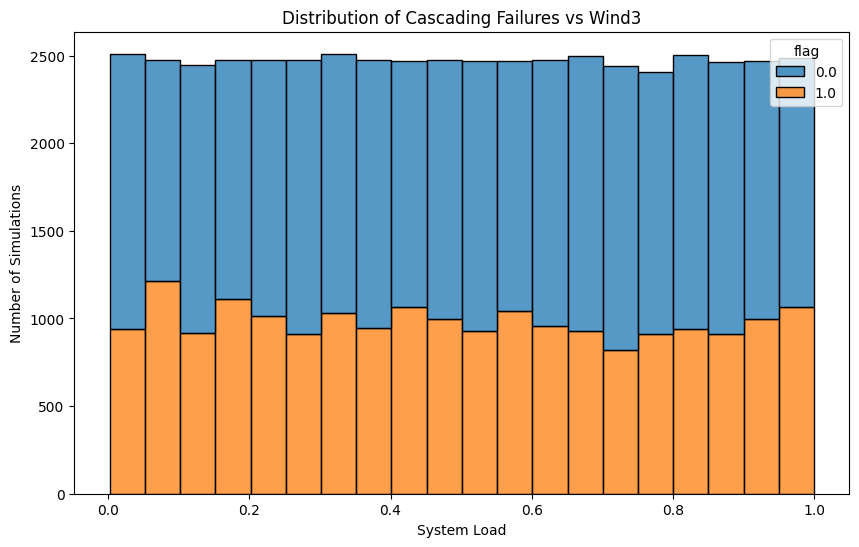

In [64]:
for features in ['Wind1', 'Wind2', 'Wind3']:
    plt.figure(figsize=(10,6))
    sns.histplot(data=filtered, x=features, hue='flag', multiple='stack', bins=20)
    plt.title(f"Distribution of Cascading Failures vs {features}")
    plt.xlabel("System Load")
    plt.ylabel("Number of Simulations")
    plt.show()

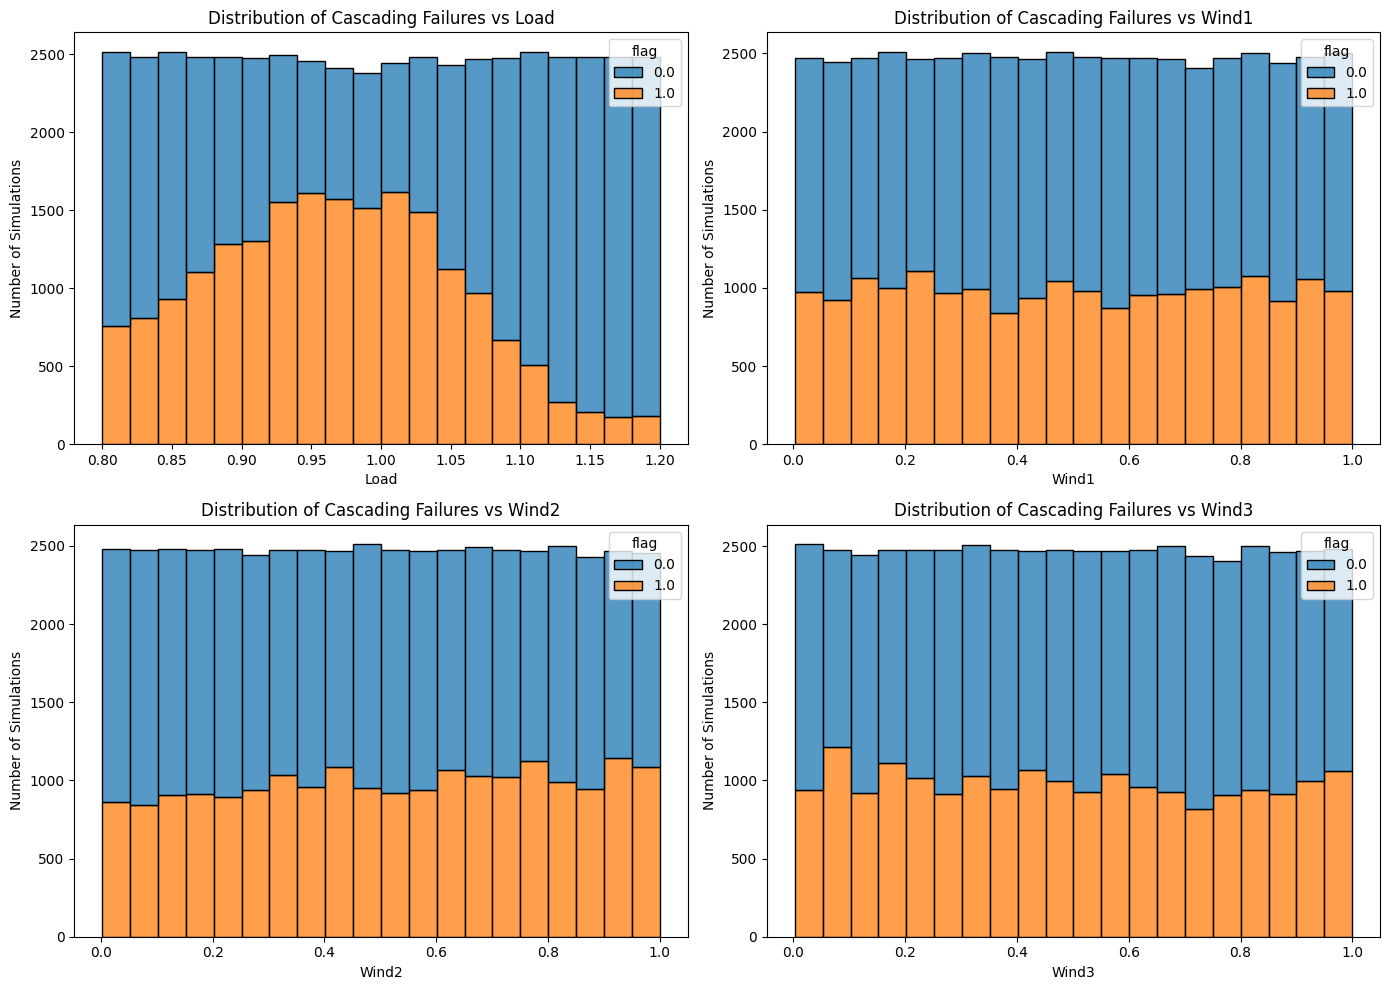

In [16]:
import matplotlib.pyplot as plt
import seaborn as sns

# Keep only flag 0 and 1
filtered = summary[summary["flag"].isin([0, 1])].copy()

features = ["Load", "Wind1", "Wind2", "Wind3"]

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

for ax, feature in zip(axes.flat, features):
    sns.histplot(
        data=filtered,
        x=feature,
        hue="flag",
        multiple="stack",
        bins=20,
        ax=ax
    )
    ax.set_title(f"Distribution of Cascading Failures vs {feature}")
    ax.set_xlabel(feature)
    ax.set_ylabel("Number of Simulations")

plt.tight_layout()
plt.show()

In [67]:
import ast
import re

def safe_parse_sequence(x):
    if not isinstance(x, str):
        return None


    try:
        result = ast.literal_eval(x)
        if isinstance(result, list):
            return result
    except Exception:
        pass

    try:
        
        joined = ", ".join(re.findall(r"\([^)]+\)", x))
        if joined:
            return ast.literal_eval(f"[{joined}]")
    except Exception:
        pass

    return None

seq_list = summary.copy()
seq_list["Sequence"] = seq_list["Sequence"].apply(safe_parse_sequence)

print("Printed below are the parsed version of the sequence of events that occur in the simulations.")
# Check a few examples
for seq in seq_list["Sequence"].head(10):
    print(seq, "\n")


Printed below are the parsed version of the sequence of events that occur in the simulations.
[('Line 04 - 05DR1', '1.04'), ('Line 04 - 05DR2', '1.04'), ('Line 01 - 39DR2', '1.47'), ('Line 08 - 09DR1', '2.40'), ('Line 08 - 09DR2', '2.42'), ('NSG_2', 'OverVoltage', '2.55'), ('NSG_1', 'OverVoltage(1)', '2.55'), ('NSG_3', 'OverVoltage(2)', '2.55'), ('G 01', 'Under-Speed', '3.63')] 

[('Line 06 - 07DR1', '1.04'), ('Line 06 - 07DR2', '1.04'), ('Line 01 - 39DR2', '3.04'), ('Line 08 - 09DR1', '3.80'), ('NSG_2', 'OverVoltage', '3.95'), ('NSG_1', 'OverVoltage(1)', '3.95'), ('NSG_3', 'OverVoltage(2)', '3.95'), ('G 01', 'Under-Speed', '4.95')] 

[('Line 06 - 11DR1', '1.04'), ('Line 06 - 11DR2', '1.04'), ('Line 01 - 39DR2', '3.10'), ('Line 08 - 09DR1', '3.87'), ('NSG_2', 'OverVoltage', '4.02'), ('NSG_1', 'OverVoltage(1)', '4.03'), ('NSG_3', 'OverVoltage(2)', '4.03'), ('G 01', 'Under-Speed', '5.04')] 

[('Line 10 - 11DR2', '1.04'), ('Line 10 - 11DR1', '1.04'), ('Line 01 - 39DR2', '3.07'), ('Line 08

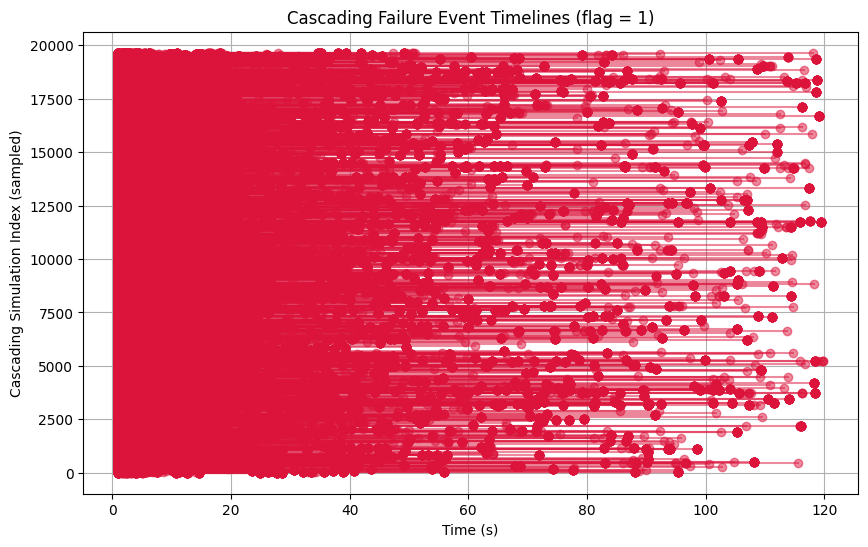

In [73]:
cascade_subset = seq_list[(seq_list['flag'] == 1) & (seq_list['Sequence'].notna())]


subset = cascade_subset['Sequence']

plt.figure(figsize=(10,6))

for i, seq in enumerate(subset):
    if isinstance(seq, list):
         
        times = [float(x[-1]) for x in seq if isinstance(x, tuple) and x[-1].replace('.', '', 1).isdigit()]
        if not times:
            continue
        plt.plot(times, [i]*len(times), 'o-', alpha=0.5, color='crimson')

plt.xlabel("Time (s)")
plt.ylabel("Cascading Simulation Index (sampled)")
plt.title("Cascading Failure Event Timelines (flag = 1)")
plt.grid(True)
plt.show()


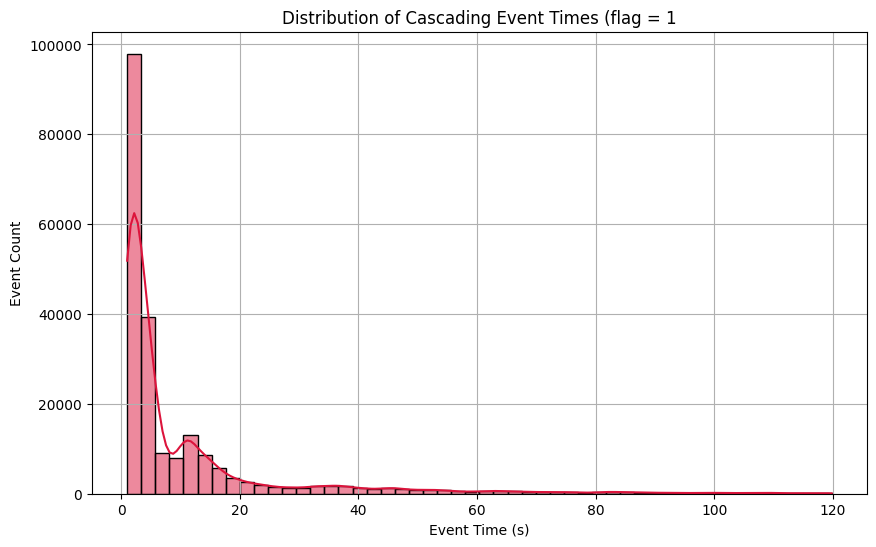

In [74]:
# Collect all event times (sample first N simulations if needed)
cascade_sims = seq_list[(seq_list['flag'] == 1) & (seq_list['Sequence'].notna())]
rows = []
for seq in cascade_sims['Sequence']:
    if isinstance(seq, list):
        for x in seq:
            if len(x) >= 2 and isinstance(x[-1], str) and x[-1].replace('.', '', 1).isdigit():
                rows.append(float(x[-1]))

plt.figure(figsize=(10,6))
sns.histplot(rows, bins=50, color='crimson', kde=True)
plt.title('Distribution of Cascading Event Times (flag = 1')
plt.xlabel('Event Time (s)')
plt.ylabel('Event Count')
plt.grid(True)
plt.show()